<a href="https://colab.research.google.com/github/InowaR/colab/blob/main/PhaseCorrelate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

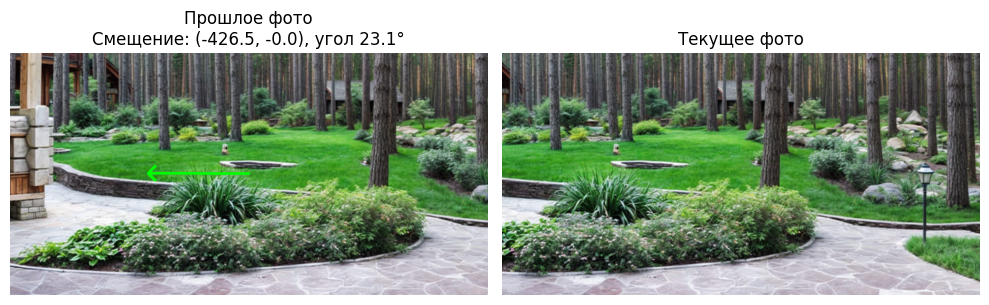

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Загрузка
img1 = cv2.imread("1.png")
img2 = cv2.imread("2.png")
img1_rgb = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
img2_rgb = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

# Расчет смещения
gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)
shift, _ = cv2.phaseCorrelate(np.float32(gray1), np.float32(gray2))

# Параметры камеры (можно настроить под вашу камеру)
focal_length = 1000  # фокусное расстояние в пикселях (типичное значение для веб-камеры)

# Перевод смещения в градусы поворота
angle_x = np.degrees(np.arctan2(shift[0], focal_length))
angle_y = np.degrees(np.arctan2(shift[1], focal_length))
angle_total = np.sqrt(angle_x**2 + angle_y**2)

# Рисуем стрелку
h, w = gray1.shape
start = (w//2, h//2)
end = (int(start[0] + shift[0]), int(start[1] + shift[1]))

cv2.arrowedLine(img1_rgb, start, end, (0, 255, 0), 10)

# Отображение рядом
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
ax1.imshow(img1_rgb)
ax1.set_title(f'Прошлое фото\nСмещение: ({shift[0]:.1f}, {shift[1]:.1f}), угол {angle_total:.1f}°')
ax1.axis('off')
ax2.imshow(img2_rgb)
ax2.set_title('Текущее фото')
ax2.axis('off')
plt.tight_layout()
plt.show()